# 4. Modélisation supervisée et semi-supervisée par fine-tuning ResNet18

Objectif : comparer les mémes trois stratégies que dans `4_bis_modeling.ipynb`, mais en remplaéant la régression logistique sur embeddings par un classifieur image fine-tuné à partir de ResNet18 préentraîné.

Les embeddings ResNet18 restent utilisés uniquement pour la sélection des pseudo-labels par clustering. Le modéle final, lui, reéoit les images et ajuste les derniéres couches de ResNet18.


## Méthodologie

Trois méthodes sont comparées :

1. baseline supervisée : fine-tuning ResNet18 uniquement sur les images fortement labellisées ;
2. semi-supervisé KMeans sélectif : ajout des images non labellisées appartenant é des clusters trés purs ;
3. semi-supervisé DBSCAN sélectif : même principe, avec des clusters DBSCAN.

L'évaluation se fait uniquement sur des images avec labels forts. Les pseudo-labels ne sont jamais utilisés dans les jeux de test.


In [25]:
# Imports
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet18_Weights

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42
OUTPUT_DIR = Path("data/processed")
FEATURES_PATH = OUTPUT_DIR / "resnet18_features.csv"
TEST_SIZE = 0.50

LABEL_TO_ID = {"normal": 0, "cancer": 1}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}

BATCH_SIZE = 16
NUM_EPOCHS = 8
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()


c:\Users\louis\Documents_locaux\LC_10\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [26]:
# Chargement des métadonnées enrichies avec embeddings
features_df = pd.read_csv(FEATURES_PATH)
feature_columns = [col for col in features_df.columns if col.startswith("feature_")]

features_df["path"] = features_df["path"].astype(str)
strong_df = features_df[features_df["label"].isin(["normal", "cancer"])].copy()
unknown_df = features_df[features_df["label"].eq("unknown")].copy()

print("Images labellisées:", strong_df.shape)
print(strong_df["label"].value_counts())
print("Images non labellisées:", unknown_df.shape)
print("Nombre de features d'embedding disponibles pour le clustering:", len(feature_columns))


Images labellisées: (100, 515)
label
cancer    50
normal    50
Name: count, dtype: int64
Images non labellisées: (1406, 515)
Nombre de features d'embedding disponibles pour le clustering: 512


## Dataset image et modèle

Le dataset lit les fichiers image depuis `path`, applique les transformations attendues par ResNet18 préentraéné, puis retourne aussi `sample_weight`. Les labels forts ont un poids de `1.0`; les pseudo-labels reéoivent un poids faible, par exemple `0.01`.


In [27]:
weights = ResNet18_Weights.DEFAULT
preprocess = weights.transforms()


class BrainMRIDataset(Dataset):
    def __init__(self, df, label_col="training_label", transform=preprocess):
        self.df = df.reset_index(drop=True).copy()
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        image = self.transform(image)
        label = LABEL_TO_ID[row[self.label_col]]
        sample_weight = float(row.get("sample_weight", 1.0))
        return image, torch.tensor(label, dtype=torch.long), torch.tensor(sample_weight, dtype=torch.float32)


def make_loader(df, label_col="training_label", shuffle=False):
    dataset = BrainMRIDataset(df, label_col=label_col)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


def make_resnet18_classifier():
    model = models.resnet18(weights=weights)

    # Petit jeu labellisé : on fine-tune seulement le dernier bloc convolutif et la téte.
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, len(LABEL_TO_ID))
    return model.to(device)


def train_resnet18(train_df, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, verbose=True):
    set_seed()
    model = make_resnet18_classifier()
    loader = make_loader(train_df, label_col="training_label", shuffle=True)

    optimizer = torch.optim.AdamW(
        [param for param in model.parameters() if param.requires_grad],
        lr=lr,
        weight_decay=WEIGHT_DECAY,
    )
    criterion = nn.CrossEntropyLoss(reduction="none")

    history = []
    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        n_seen = 0

        for images, labels, sample_weights in loader:
            images = images.to(device)
            labels = labels.to(device)
            sample_weights = sample_weights.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            losses = criterion(logits, labels)
            loss = (losses * sample_weights).sum() / sample_weights.sum().clamp_min(1e-8)
            loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            n_seen += batch_size

        epoch_loss = running_loss / max(n_seen, 1)
        history.append({"epoch": epoch, "train_loss": epoch_loss})
        if verbose:
            print(f"Epoch {epoch:02d}/{num_epochs} - train_loss={epoch_loss:.4f}")

    return model, pd.DataFrame(history)


def predict_resnet18(model, df, label_col="label"):
    loader = make_loader(df, label_col=label_col, shuffle=False)
    model.eval()
    predictions = []

    with torch.no_grad():
        for images, _, _ in loader:
            images = images.to(device)
            logits = model(images)
            pred_ids = logits.argmax(dim=1).cpu().numpy()
            predictions.extend([ID_TO_LABEL[int(pred_id)] for pred_id in pred_ids])

    return np.array(predictions)


def compute_metrics(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_cancer": f1_score(y_true, y_pred, pos_label="cancer", zero_division=0),
        "recall_cancer": recall_score(y_true, y_pred, pos_label="cancer", zero_division=0),
        "precision_cancer": precision_score(y_true, y_pred, pos_label="cancer", zero_division=0),
    }


def evaluate_resnet18(model, test_df, model_name):
    y_true = test_df["label"].values
    y_pred = predict_resnet18(model, test_df, label_col="label")
    metrics = compute_metrics(y_true, y_pred, model_name)
    print(model_name)
    print(classification_report(y_true, y_pred, zero_division=0))
    return metrics, y_pred


## Split final

Le split final conserve uniquement les labels forts. Il donne une comparaison lisible, mais la validation croisée reste la comparaison principale car le jeu labellisé est petit.


In [28]:
train_idx, test_idx = train_test_split(
    strong_df.index,
    test_size=TEST_SIZE,
    stratify=strong_df["label"],
    random_state=RANDOM_STATE,
)

train_strong_df = strong_df.loc[train_idx].copy()
test_strong_df = strong_df.loc[test_idx].copy()

train_strong_df["training_label"] = train_strong_df["label"]
train_strong_df["sample_weight"] = 1.0

y_test = test_strong_df["label"].values

print("Train fort:")
print(train_strong_df["label"].value_counts())
print("Test fort:")
print(test_strong_df["label"].value_counts())


Train fort:
label
cancer    25
normal    25
Name: count, dtype: int64
Test fort:
label
normal    25
cancer    25
Name: count, dtype: int64


In [29]:
# Baseline supervisée : fine-tuning ResNet18 sur labels forts uniquement
supervised_model, supervised_history = train_resnet18(train_strong_df, verbose=True)
supervised_metrics, supervised_pred = evaluate_resnet18(
    supervised_model,
    test_strong_df,
    "supervised_resnet18_finetune",
)
supervised_metrics


Epoch 01/8 - train_loss=0.6054
Epoch 02/8 - train_loss=0.0944
Epoch 03/8 - train_loss=0.0399
Epoch 04/8 - train_loss=0.0618
Epoch 05/8 - train_loss=0.0330
Epoch 06/8 - train_loss=0.0037
Epoch 07/8 - train_loss=0.0273
Epoch 08/8 - train_loss=0.0971
supervised_resnet18_finetune
              precision    recall  f1-score   support

      cancer       0.89      0.96      0.92        25
      normal       0.96      0.88      0.92        25

    accuracy                           0.92        50
   macro avg       0.92      0.92      0.92        50
weighted avg       0.92      0.92      0.92        50



{'model': 'supervised_resnet18_finetune',
 'accuracy': 0.92,
 'precision_macro': 0.9227053140096618,
 'recall_macro': 0.9199999999999999,
 'f1_macro': 0.9198717948717949,
 'f1_cancer': 0.9230769230769231,
 'recall_cancer': 0.96,
 'precision_cancer': 0.8888888888888888}

## Construction sélective des pseudo-labels

Les pseudo-labels sont construits comme dans `4_bis_modeling.ipynb` : les clusters sont calculés sur les embeddings, puis seuls les clusters suffisamment purs dans les labels forts du train sont retenus.


In [30]:
def assign_clusters(df, feature_columns, method, **config):
    X = df[feature_columns].values

    if method == "kmeans":
        clustering_model = make_pipeline(
            StandardScaler(),
            KMeans(
                n_clusters=config["k"],
                random_state=RANDOM_STATE,
                n_init=10,
            ),
        )
        return clustering_model.fit_predict(X)

    if method == "dbscan":
        clustering_model = make_pipeline(
            StandardScaler(),
            DBSCAN(
                eps=config["eps"],
                min_samples=config["min_samples"],
            ),
        )
        return clustering_model.fit_predict(X)

    raise ValueError(f"Unknown clustering method: {method}")


def build_selective_pseudo_labels(
    train_strong_df,
    unknown_df,
    feature_columns,
    method,
    purity_threshold=0.95,
    min_labeled_per_cluster=2,
    pseudo_weight=0.01,
    mode="both",
    **cluster_config,
):
    pseudo_source_df = pd.concat([train_strong_df, unknown_df], axis=0).copy()
    pseudo_source_df["cluster_modeling"] = assign_clusters(
        pseudo_source_df,
        feature_columns,
        method=method,
        **cluster_config,
    )

    if method == "dbscan":
        pseudo_source_df = pseudo_source_df[pseudo_source_df["cluster_modeling"].ne(-1)].copy()

    train_with_clusters = pseudo_source_df[pseudo_source_df["label"].isin(["normal", "cancer"])].copy()
    unknown_with_clusters = pseudo_source_df[pseudo_source_df["label"].eq("unknown")].copy()

    cluster_counts = pd.crosstab(
        train_with_clusters["cluster_modeling"],
        train_with_clusters["label"],
    )

    for label in ["cancer", "normal"]:
        if label not in cluster_counts.columns:
            cluster_counts[label] = 0

    cluster_counts = cluster_counts[["cancer", "normal"]]
    cluster_stats = cluster_counts.copy()
    cluster_stats["n_labeled"] = cluster_stats.sum(axis=1)
    cluster_stats["majority_label"] = cluster_counts.idxmax(axis=1)
    cluster_stats["purity"] = cluster_counts.max(axis=1) / cluster_stats["n_labeled"]

    selected_clusters = cluster_stats[
        (cluster_stats["n_labeled"] >= min_labeled_per_cluster)
        & (cluster_stats["purity"] >= purity_threshold)
    ].copy()

    if mode == "cancer_only":
        selected_clusters = selected_clusters[selected_clusters["majority_label"].eq("cancer")]

    cluster_to_label = selected_clusters["majority_label"].to_dict()
    cluster_to_purity = selected_clusters["purity"].to_dict()
    cluster_to_n = selected_clusters["n_labeled"].to_dict()

    unknown_with_clusters["pseudo_label"] = unknown_with_clusters["cluster_modeling"].map(cluster_to_label)
    unknown_with_clusters["cluster_purity"] = unknown_with_clusters["cluster_modeling"].map(cluster_to_purity)
    unknown_with_clusters["cluster_labeled_count"] = unknown_with_clusters["cluster_modeling"].map(cluster_to_n)

    pseudo_labeled_df = unknown_with_clusters.dropna(subset=["pseudo_label"]).copy()

    train_for_semi = train_with_clusters.copy()
    train_for_semi["training_label"] = train_for_semi["label"]
    train_for_semi["sample_weight"] = 1.0
    train_for_semi["pseudo_label"] = np.nan
    train_for_semi["cluster_purity"] = np.nan
    train_for_semi["cluster_labeled_count"] = np.nan

    pseudo_for_semi = pseudo_labeled_df.copy()
    pseudo_for_semi["training_label"] = pseudo_for_semi["pseudo_label"]
    pseudo_for_semi["sample_weight"] = pseudo_weight

    semi_train_df = pd.concat([train_for_semi, pseudo_for_semi], axis=0)

    return semi_train_df, pseudo_labeled_df, cluster_stats, selected_clusters


In [31]:
KMEANS_CONFIG = {
    "method": "kmeans",
    "k": 10,
    "purity_threshold": 0.95,
    "min_labeled_per_cluster": 2,
    "pseudo_weight": 0.01,
    "mode": "both",
}

DBSCAN_CONFIG = {
    "method": "dbscan",
    "eps": 21.5,
    "min_samples": 12,
    "purity_threshold": 0.95,
    "min_labeled_per_cluster": 2,
    "pseudo_weight": 0.01,
    "mode": "both",
}

MODEL_CONFIGS = {
    "kmeans_selective": KMEANS_CONFIG,
    "dbscan_selective": DBSCAN_CONFIG,
}


In [32]:
def fit_semi_supervised_resnet18(train_strong_df, unknown_df, config, model_name):
    semi_train_df, pseudo_labeled_df, cluster_stats, selected_clusters = build_selective_pseudo_labels(
        train_strong_df,
        unknown_df,
        feature_columns,
        **config,
    )

    print(f"{model_name}: {len(pseudo_labeled_df)} pseudo-labels retenus")
    print(pseudo_labeled_df["pseudo_label"].value_counts())

    model, history = train_resnet18(semi_train_df, verbose=True)
    metrics, predictions = evaluate_resnet18(model, test_strong_df, model_name)

    return {
        "model": model,
        "history": history,
        "metrics": metrics,
        "predictions": predictions,
        "semi_train_df": semi_train_df,
        "pseudo_labeled_df": pseudo_labeled_df,
        "cluster_stats": cluster_stats,
        "selected_clusters": selected_clusters,
    }


In [33]:
# Semi-supervisé sélectif sur le split final : KMeans vs DBSCAN
semi_results = {}

for model_name, config in MODEL_CONFIGS.items():
    semi_results[model_name] = fit_semi_supervised_resnet18(
        train_strong_df,
        unknown_df,
        config,
        f"semi_supervised_{model_name}_resnet18_finetune",
    )


semi_supervised_kmeans_selective_resnet18_finetune: 966 pseudo-labels retenus
pseudo_label
cancer    767
normal    199
Name: count, dtype: int64
Epoch 01/8 - train_loss=0.2595
Epoch 02/8 - train_loss=0.0284
Epoch 03/8 - train_loss=0.0131
Epoch 04/8 - train_loss=0.0151
Epoch 05/8 - train_loss=0.0057
Epoch 06/8 - train_loss=0.0152
Epoch 07/8 - train_loss=0.0051
Epoch 08/8 - train_loss=0.0032
semi_supervised_kmeans_selective_resnet18_finetune
              precision    recall  f1-score   support

      cancer       0.83      0.96      0.89        25
      normal       0.95      0.80      0.87        25

    accuracy                           0.88        50
   macro avg       0.89      0.88      0.88        50
weighted avg       0.89      0.88      0.88        50

semi_supervised_dbscan_selective_resnet18_finetune: 322 pseudo-labels retenus
pseudo_label
cancer    322
Name: count, dtype: int64
Epoch 01/8 - train_loss=0.7227
Epoch 02/8 - train_loss=0.1304
Epoch 03/8 - train_loss=0.0515
Epoch

In [34]:
# Vérification de fuite de données entre test final et trains semi-supervisés
test_paths = set(test_strong_df["path"])

for model_name, result in semi_results.items():
    train_paths = set(result["semi_train_df"]["path"])
    overlap = test_paths.intersection(train_paths)
    print(model_name, "overlap test/train:", len(overlap))
    assert len(overlap) == 0


kmeans_selective overlap test/train: 0
dbscan_selective overlap test/train: 0


In [35]:
metrics_df = pd.DataFrame(
    [supervised_metrics]
    + [result["metrics"] for result in semi_results.values()]
)
metrics_df


,model,accuracy,precision_macro,recall_macro,f1_macro,f1_cancer,recall_cancer,precision_cancer
0,supervised_resnet18_finetune,0.92,0.922705,0.92,0.919872,0.923077,0.96,0.888889
1,semi_supervised_kmeans_selective_resnet18_fine...,0.88,0.889984,0.88,0.879227,0.888889,0.96,0.827586
2,semi_supervised_dbscan_selective_resnet18_fine...,0.88,0.889984,0.88,0.879227,0.888889,0.96,0.827586


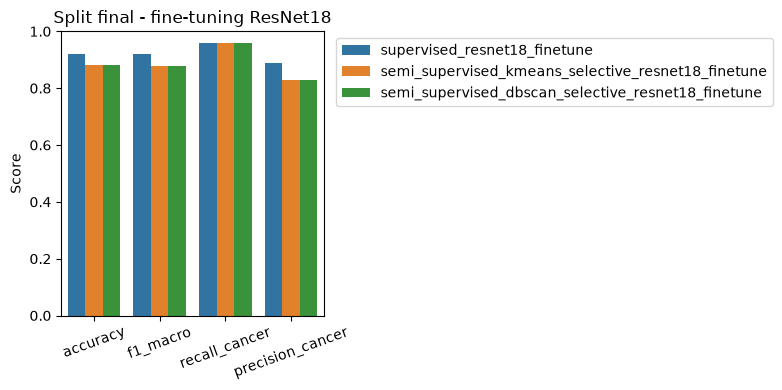

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=metrics_df.melt(id_vars="model", value_vars=["accuracy", "f1_macro", "recall_cancer", "precision_cancer"]),
    x="variable",
    y="value",
    hue="model",
    ax=ax,
)
ax.set_ylim(0, 1)
ax.set_title("Split final - fine-tuning ResNet18")
ax.set_xlabel("")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Validation croisée

La validation croisée est plus informative que le split final. Elle compare les trois méthodes sur cinq folds, avec reconstruction des pseudo-labels é l'intérieur de chaque fold pour éviter les fuites de données.


In [37]:
def append_metric_row(results, fold, model_name, y_true, y_pred, extra=None):
    row = {
        "fold": fold,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_cancer": f1_score(y_true, y_pred, pos_label="cancer", zero_division=0),
        "recall_cancer": recall_score(y_true, y_pred, pos_label="cancer", zero_division=0),
        "precision_cancer": precision_score(y_true, y_pred, pos_label="cancer", zero_division=0),
    }
    if extra:
        row.update(extra)
    results.append(row)


def supervised_cv_resnet18(strong_df, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    y = strong_df["label"].values
    results = []

    for fold, (train_pos, test_pos) in enumerate(skf.split(strong_df, y), start=1):
        print(f"\nFold {fold} - supervised ResNet18")
        train_fold = strong_df.iloc[train_pos].copy()
        test_fold = strong_df.iloc[test_pos].copy()
        train_fold["training_label"] = train_fold["label"]
        train_fold["sample_weight"] = 1.0

        model, _ = train_resnet18(train_fold, verbose=False)
        y_pred = predict_resnet18(model, test_fold, label_col="label")

        append_metric_row(
            results,
            fold,
            "supervised_resnet18_cv",
            test_fold["label"].values,
            y_pred,
            {
                "n_pseudo": 0,
                "n_pseudo_cancer": 0,
                "n_pseudo_normal": 0,
                "n_selected_clusters": 0,
            },
        )

    return pd.DataFrame(results)


def semi_supervised_selective_cv_resnet18(strong_df, unknown_df, config, model_name, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    y = strong_df["label"].values
    results = []

    for fold, (train_pos, test_pos) in enumerate(skf.split(strong_df, y), start=1):
        print(f"\nFold {fold} - {model_name}")
        train_fold = strong_df.iloc[train_pos].copy()
        test_fold = strong_df.iloc[test_pos].copy()

        semi_train_fold, pseudo_labeled_fold, _, selected_clusters_fold = build_selective_pseudo_labels(
            train_fold,
            unknown_df,
            feature_columns,
            **config,
        )

        overlap = set(test_fold["path"]).intersection(set(semi_train_fold["path"]))
        assert len(overlap) == 0

        model, _ = train_resnet18(semi_train_fold, verbose=False)
        y_pred = predict_resnet18(model, test_fold, label_col="label")
        pseudo_counts = pseudo_labeled_fold["pseudo_label"].value_counts()

        append_metric_row(
            results,
            fold,
            model_name,
            test_fold["label"].values,
            y_pred,
            {
                "n_pseudo": len(pseudo_labeled_fold),
                "n_pseudo_cancer": pseudo_counts.get("cancer", 0),
                "n_pseudo_normal": pseudo_counts.get("normal", 0),
                "n_selected_clusters": len(selected_clusters_fold),
                "pseudo_weight": config["pseudo_weight"],
                "purity_threshold": config["purity_threshold"],
                "min_labeled_per_cluster": config["min_labeled_per_cluster"],
                "clustering_method": config["method"],
            },
        )

    return pd.DataFrame(results)


In [38]:
# Validation croisée : comparaison principale
supervised_cv_df = supervised_cv_resnet18(strong_df)

semi_cv_dfs = []
for model_name, config in MODEL_CONFIGS.items():
    semi_cv_dfs.append(
        semi_supervised_selective_cv_resnet18(
            strong_df,
            unknown_df,
            config,
            f"semi_supervised_{model_name}_resnet18_cv",
        )
    )

cv_results_df = pd.concat([supervised_cv_df] + semi_cv_dfs, axis=0, ignore_index=True)
cv_results_df



Fold 1 - supervised ResNet18

Fold 2 - supervised ResNet18

Fold 3 - supervised ResNet18

Fold 4 - supervised ResNet18

Fold 5 - supervised ResNet18

Fold 1 - semi_supervised_kmeans_selective_resnet18_cv

Fold 2 - semi_supervised_kmeans_selective_resnet18_cv

Fold 3 - semi_supervised_kmeans_selective_resnet18_cv

Fold 4 - semi_supervised_kmeans_selective_resnet18_cv

Fold 5 - semi_supervised_kmeans_selective_resnet18_cv

Fold 1 - semi_supervised_dbscan_selective_resnet18_cv

Fold 2 - semi_supervised_dbscan_selective_resnet18_cv

Fold 3 - semi_supervised_dbscan_selective_resnet18_cv

Fold 4 - semi_supervised_dbscan_selective_resnet18_cv

Fold 5 - semi_supervised_dbscan_selective_resnet18_cv


,fold,model,accuracy,f1_macro,f1_cancer,recall_cancer,precision_cancer,n_pseudo,n_pseudo_cancer,n_pseudo_normal,n_selected_clusters,pseudo_weight,purity_threshold,min_labeled_per_cluster,clustering_method
0,1,supervised_resnet18_cv,0.95,0.949875,0.952381,1.0,0.909091,0,0,0,0,NaN,NaN,NaN,NaN
1,2,supervised_resnet18_cv,0.95,0.949875,0.952381,1.0,0.909091,0,0,0,0,NaN,NaN,NaN,NaN
2,3,supervised_resnet18_cv,0.95,0.949875,0.947368,0.9,1.000000,0,0,0,0,NaN,NaN,NaN,NaN
3,4,supervised_resnet18_cv,0.90,0.898990,0.909091,1.0,0.833333,0,0,0,0,NaN,NaN,NaN,NaN
4,5,supervised_resnet18_cv,0.95,0.949875,0.947368,0.9,1.000000,0,0,0,0,NaN,NaN,NaN,NaN
5,1,semi_supervised_kmeans_selective_resnet18_cv,0.95,0.949875,0.952381,1.0,0.909091,538,447,91,4,0.01,0.95,2.0,kmeans
6,2,semi_supervised_kmeans_selective_resnet18_cv,0.95,0.949875,0.952381,1.0,0.909091,479,479,0,3,0.01,0.95,2.0,kmeans
7,3,semi_supervised_kmeans_selective_resnet18_cv,0.95,0.949875,0.947368,0.9,1.000000,561,447,114,4,0.01,0.95,2.0,kmeans
8,4,semi_supervised_kmeans_selective_resnet18_cv,0.95,0.949875,0.952381,1.0,0.909091,743,619,124,5,0.01,0.95,2.0,kmeans
9,5,semi_supervised_kmeans_selective_resnet18_cv,0.95,0.949875,0.947368,0.9,1.000000,691,499,192,5,0.01,0.95,2.0,kmeans


In [39]:
cv_summary = (
    cv_results_df
    .groupby("model")
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_macro_mean=("f1_macro", "mean"),
        f1_macro_std=("f1_macro", "std"),
        recall_cancer_mean=("recall_cancer", "mean"),
        precision_cancer_mean=("precision_cancer", "mean"),
        n_pseudo_mean=("n_pseudo", "mean"),
    )
    .reset_index()
)
cv_summary


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,recall_cancer_mean,precision_cancer_mean,n_pseudo_mean
0,semi_supervised_dbscan_selective_resnet18_cv,0.93,0.044721,0.929825,0.044833,0.94,0.927273,263.8
1,semi_supervised_kmeans_selective_resnet18_cv,0.95,0.000000,0.949875,0.000000,0.96,0.945455,602.4
2,supervised_resnet18_cv,0.94,0.022361,0.939698,0.022756,0.96,0.930303,0.0


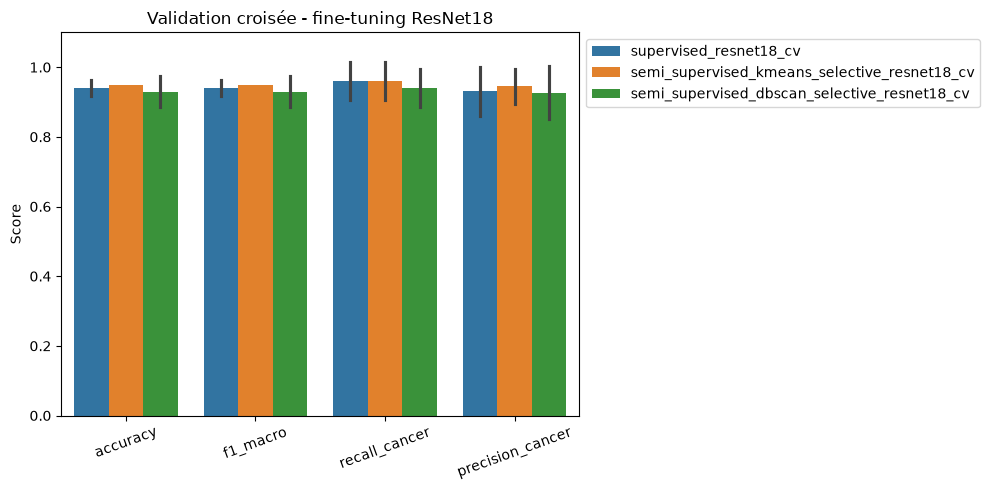

In [46]:
metrics_to_plot = ["accuracy", "f1_macro", "recall_cancer", "precision_cancer"]
plot_df = cv_results_df.melt(
    id_vars=["fold", "model"],
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model", errorbar="sd", ax=ax)
ax.set_ylim(0, 1.1)
ax.set_title("Validation croisée - fine-tuning ResNet18")
ax.set_xlabel("")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Interprétation attendue

Cette version teste si le fine-tuning direct du CNN exploite mieux les images que la régression logistique sur embeddings figés. Les points à comparer avec `4_bis_modeling.ipynb` sont :

- performance absolue du ResNet18 fine-tuné par rapport à la régression logistique ;
- gain ou dégradation quand les pseudo-labels sont ajoutés ;
- stabilité entre folds ;
- évolution de la précision et du rappel de la classe `cancer`.

Si le fine-tuning n'améliore pas la baseline, cela peut indiquer que les 100 labels forts sont insuffisants pour ajuster un CNN sans surapprentissage. Si KMeans améliore surtout la précision cancer, cela confirmerait l'observation de la version embeddings. Si DBSCAN dégrade encore les scores, cela renforcerait l'idée que ses pseudo-labels sont moins alignés avec la frontiére de classification.


In [41]:
# Sauvegardes dédiées à la version CNN pour ne pas écraser les résultats de 4_bis
metrics_path = OUTPUT_DIR / "modeling_metrics_cnn_selective.csv"
cv_results_path = OUTPUT_DIR / "modeling_cv_results_cnn_selective.csv"
cv_summary_path = OUTPUT_DIR / "modeling_cv_summary_cnn_selective.csv"

metrics_df.to_csv(metrics_path, index=False)
cv_results_df.to_csv(cv_results_path, index=False)
cv_summary.to_csv(cv_summary_path, index=False)

for model_name, result in semi_results.items():
    prefix = MODEL_CONFIGS[model_name]["method"]
    result["pseudo_labeled_df"].to_csv(
        OUTPUT_DIR / f"pseudo_labels_{prefix}_cnn_selective.csv",
        index=False,
    )
    result["semi_train_df"].to_csv(
        OUTPUT_DIR / f"semi_supervised_training_set_{prefix}_cnn_selective.csv",
        index=False,
    )
    result["cluster_stats"].to_csv(
        OUTPUT_DIR / f"{prefix}_cluster_purity_cnn_modeling.csv",
    )
    result["selected_clusters"].to_csv(
        OUTPUT_DIR / f"{prefix}_selected_clusters_cnn_modeling.csv",
    )

print("Final split metrics:", metrics_path)
print("CV results:", cv_results_path)
print("CV summary:", cv_summary_path)


Final split metrics: data\processed\modeling_metrics_cnn_selective.csv
CV results: data\processed\modeling_cv_results_cnn_selective.csv
CV summary: data\processed\modeling_cv_summary_cnn_selective.csv


## Definition of Done - étape 4 CNN

L'étape 4 CNN est terminée si :

- la baseline supervisée fine-tune ResNet18 sur les images labellisées ;
- les variantes semi-supervisées KMeans et DBSCAN utilisent les mémes régles sélectives que `4_bis_modeling.ipynb` ;
- aucune image du fold de test n'entre dans les données d'entraénement, méme via pseudo-label ;
- les résultats du split final et de la validation croisée sont sauvegardés avec le suffixe `_cnn_selective` ;
- l'interprétation compare explicitement le CNN fine-tuné é la version régression logistique sur embeddings.
